NOT USED BECAUSE FOR SOME REASON THE R PACKAGE WORKS BETTER!!!! see powerLaw.r

Clauset 2009 paper package to detect power laws

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import powerlaw
import csv
import pandas as pd

In [8]:
# Files used here are generated by process_data_degSeq.py

cutoff = 0.1 # 0.05, 0.1, 0.15, 0.2
nSpec = 1000 # "" or "500" "1000"

# Initialize empty DataFrame with column names
df = pd.DataFrame(columns=[
    'degDistType', 'iteration', 'R_exp_cooc', 'p_exp_cooc',
    'R_logn_cooc', 'p_logn_cooc', 'R_trunc_cooc', 'p_trunc_cooc',
    'R_exp_inter', 'p_exp_inter', 'R_logn_inter', 'p_logn_inter',
    'R_trunc_inter', 'p_trunc_inter', 'cooc_alpha', 'cooc_xmin',
    'inter_alpha', 'inter_xmin'
])

for trueType in ["power", "exp", "rand"]:
    for i in range(10):
        # print(trueType)
        # print(i)

        filenameCooc = "/home/fiona_callahan/TheoryCoOccur/degree_sequences/cooc/cooc_nodeDegree" + str(nSpec) + "_" + trueType + "_cutoff" + str(cutoff) + "_" + str(i) + ".csv"
        filenameInter = "/home/fiona_callahan/TheoryCoOccur/degree_sequences/inter/inter_nodeDegree" + str(nSpec) + "_" + trueType + "_" + str(i) + ".csv"

        cooc_df = pd.read_csv(filenameCooc, delimiter=',', quotechar='|', header=0)
        inter_df = pd.read_csv(filenameInter, delimiter=',', quotechar='|', header=0)

        degreeDistCooc = cooc_df.iloc[:, 1].astype(float).values
        degreeDistInter = inter_df.iloc[:, 1].astype(float).values

        powLaw_cooc = powerlaw.Fit(degreeDistCooc, fit_method= "KS", parameter_range = {"alpha": (1, 4)})
        #powLaw_cooc = powerlaw.Fit(degreeDistCooc, discrete = True, fit_method= "KS")
        # print(powLaw_cooc.power_law.alpha)
        # print(powLaw_cooc.power_law.xmin)
        # len([d for d in degreeDistCooc if d>powLaw_cooc.power_law.xmin])
        R_exp_cooc, p_exp_cooc = powLaw_cooc.distribution_compare('power_law', 'exponential')
        R_logn_cooc, p_logn_cooc = powLaw_cooc.distribution_compare('power_law', 'lognormal')
        R_trunc_cooc, p_trunc_cooc = powLaw_cooc.distribution_compare('power_law', 'truncated_power_law')

        # print(f'For coocurrence network power law versus exponential: R={R_exp_cooc} and p={p_exp_cooc}')
        # print(f'For coocurrence network power law versus lognormal: R={R_logn_cooc} and p={p_logn_cooc}')
        # print(f'For coocurrence network power law versus truncated power law: R={R_trunc_cooc} and p={p_trunc_cooc}')

        powLaw_inter = powerlaw.Fit(degreeDistInter, fit_method= "KS", parameter_range = {"alpha": (1, 4)})
        #powLaw_inter = powerlaw.Fit(degreeDistInter, discrete = True, fit_method= "KS")
        # print(powLaw_inter.power_law.alpha)
        # print(powLaw_inter.power_law.xmin)
        # Loglikelihood ratio of the two distributions' fit to the data. If greater than 0, the first distribution is preferred. If less than 0, the second distribution is preferred.
        R_exp_inter, p_exp_inter = powLaw_inter.distribution_compare('power_law', 'exponential')
        R_logn_inter, p_logn_inter = powLaw_inter.distribution_compare('power_law', 'lognormal')
        R_trunc_inter, p_trunc_inter = powLaw_inter.distribution_compare('power_law', 'truncated_power_law')

        # print(f'For interaction network power law versus exponential: R={R_exp_inter} and p={p_exp_inter}')
        # print(f'For interaction network power law versus lognormal: R={R_logn_inter} and p={p_logn_inter}')
        # print(f'For interaction network power law versus truncated power law: R={R_trunc_inter} and p={p_trunc_inter}')
        
        # Add row to DataFrame
        new_row = pd.DataFrame({
            'degDistType': [trueType],
            'iteration': [i],
            'R_exp_cooc': [R_exp_cooc],
            'p_exp_cooc': [p_exp_cooc],
            'R_logn_cooc': [R_logn_cooc],
            'p_logn_cooc': [p_logn_cooc],
            'R_trunc_cooc': [R_trunc_cooc],
            'p_trunc_cooc': [p_trunc_cooc],
            'R_exp_inter': [R_exp_inter],
            'p_exp_inter': [p_exp_inter],
            'R_logn_inter': [R_logn_inter],
            'p_logn_inter': [p_logn_inter],
            'R_trunc_inter': [R_trunc_inter],
            'p_trunc_inter': [p_trunc_inter],
            'cooc_alpha': [powLaw_cooc.power_law.alpha],
            'cooc_xmin': [powLaw_cooc.power_law.xmin],
            'inter_alpha': [powLaw_inter.power_law.alpha],
            'inter_xmin': [powLaw_inter.power_law.xmin]
        })
        df = pd.concat([df, new_row], ignore_index=True)

Calculating best minimal value for power law fit
/space/s1/fiona_callahan/miniforge3/envs/python_nb/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
Assuming nested distributions
Calculating best minimal value for power law fit
Assuming nested distributions
/space/s1/fiona_callahan/miniforge3/envs/python_nb/lib/python3.13/site-packages/powerlaw.py:698: RuntimeWarning: overflow encountered in scalar add
  self.Asquare = sum((
/tmp/ipykernel_573483/1843154611.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)
Calculating best minimal value for power law fit
/space/s1/fiona_callahan/miniforge3/envs/python_nb/lib/python3.13/site

Look at results

In [9]:
result = df.groupby('degDistType').mean().round(3)
result

,iteration,R_exp_cooc,p_exp_cooc,R_logn_cooc,p_logn_cooc,R_trunc_cooc,p_trunc_cooc,R_exp_inter,p_exp_inter,R_logn_inter,p_logn_inter,R_trunc_inter,p_trunc_inter,cooc_alpha,cooc_xmin,inter_alpha,inter_xmin
degDistType,,,,,,,,,,,,,,,,,
exp,4.5,-89.400,0.0,-253.588,0.0,-65.621,0.0,-2.389,0.352,-2.207,0.438,-2.895,0.036,3.659,16.5,3.726,18.9
power,4.5,-87.844,0.0,-264.170,0.0,-63.273,0.0,111.405,0.000,3.392,0.208,2.292,0.184,3.693,16.4,3.047,8.5
rand,4.5,-87.313,0.0,-258.510,0.0,-63.051,0.0,-54.726,0.000,-88.000,0.000,-36.524,0.000,3.716,16.4,3.520,7.3


This one runs the above analysis but only once

power
0


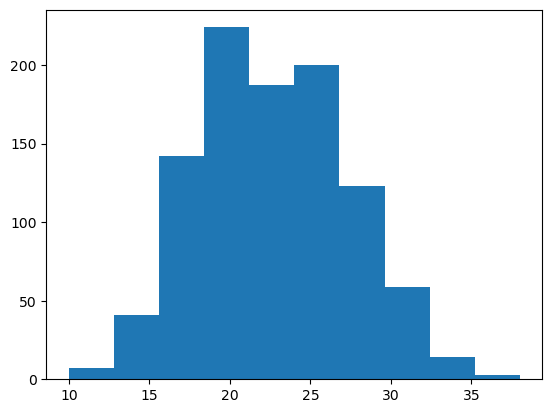

Calculating best minimal value for power law fit
/space/s1/fiona_callahan/miniforge3/envs/python_nb/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
Assuming nested distributions


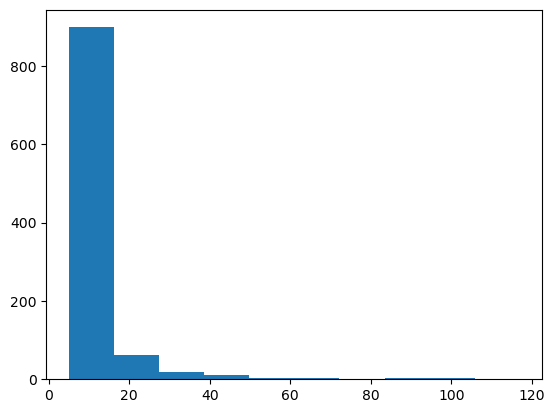

Calculating best minimal value for power law fit
/space/s1/fiona_callahan/miniforge3/envs/python_nb/lib/python3.13/site-packages/powerlaw.py:1605: RuntimeWarning: invalid value encountered in divide
  CDF = CDF/norm
'nan' in fit cumulative distribution values.
Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.
Assuming nested distributions


In [10]:
# Files used here are generated by process_data_degSeq.py
cutoff = 0.1 # 0.05, 0.1, 0.15, 0.2
nSpec = 1000 # "" or "500" "1000"

trueType = "power"
i=0

print(trueType)
print(i)

filenameCooc = "/home/fiona_callahan/TheoryCoOccur/degree_sequences/cooc/cooc_nodeDegree" + str(nSpec) + "_" + trueType + "_cutoff" + str(cutoff) + "_" + str(i) + ".csv"
filenameInter = "/home/fiona_callahan/TheoryCoOccur/degree_sequences/inter/inter_nodeDegree" + str(nSpec) + "_" + trueType + "_" + str(i) + ".csv"

# read files
data = []
with open(filenameCooc, newline='') as csvfile:
    spamreader = csv.reader(csvfile, delimiter=',', quotechar='|')
    for row in spamreader:
        data.append(row)
cooc_np = np.array(data)

data = []
with open(filenameInter, newline='') as csvfile:
    spamreader = csv.reader(csvfile, delimiter=',', quotechar='|')
    for row in spamreader:
        data.append(row)
inter_np = np.array(data)

degreeDistCooc = cooc_np[1:,1].astype(float)
plt.hist(degreeDistCooc)
plt.show()

powLaw_cooc = powerlaw.Fit(degreeDistCooc)
# print(powLaw_cooc.power_law.alpha)
# print(powLaw_cooc.power_law.xmin)
# len([d for d in degreeDistCooc if d>powLaw_cooc.power_law.xmin])
R_exp_cooc, p_exp_cooc = powLaw_cooc.distribution_compare('power_law', 'exponential')
R_logn_cooc, p_logn_cooc = powLaw_cooc.distribution_compare('power_law', 'lognormal')
R_trunc_cooc, p_trunc_cooc = powLaw_cooc.distribution_compare('power_law', 'truncated_power_law')

# print(f'For coocurrence network power law versus exponential: R={R_exp_cooc} and p={p_exp_cooc}')
# print(f'For coocurrence network power law versus lognormal: R={R_logn_cooc} and p={p_logn_cooc}')
# print(f'For coocurrence network power law versus truncated power law: R={R_trunc_cooc} and p={p_trunc_cooc}')

degreeDistInter = inter_np[1:,1].astype(float)
plt.hist(degreeDistInter)
plt.show()
powLaw_inter = powerlaw.Fit(degreeDistInter)
# print(powLaw_inter.power_law.alpha)
# print(powLaw_inter.power_law.xmin)
# Loglikelihood ratio of the two distributions’ fit to the data. If greater than 0, the first distribution is preferred. If less than 0, the second distribution is preferred.
R_exp_inter, p_exp_inter = powLaw_inter.distribution_compare('power_law', 'exponential')
R_logn_inter, p_logn_inter = powLaw_inter.distribution_compare('power_law', 'lognormal')
R_trunc_inter, p_trunc_inter = powLaw_inter.distribution_compare('power_law', 'truncated_power_law')

# print(f'For interaction network power law versus exponential: R={R_exp_inter} and p={p_exp_inter}')
# print(f'For interaction network power law versus lognormal: R={R_logn_inter} and p={p_logn_inter}')
# print(f'For interaction network power law versus truncated power law: R={R_trunc_inter} and p={p_trunc_inter}')

This one is just a test if we generate a powerlaw distribution ourselves and then try to fit it
https://stackoverflow.com/questions/31114330/python-generating-random-numbers-from-a-power-law-distribution

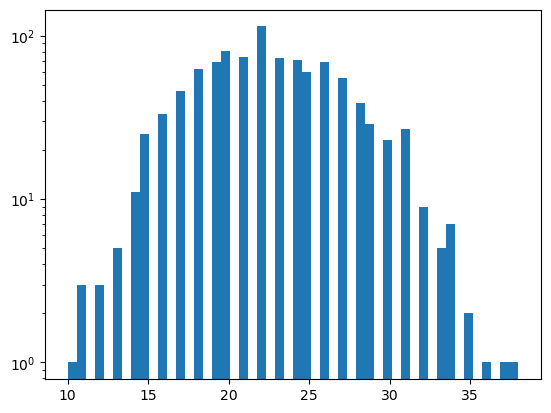

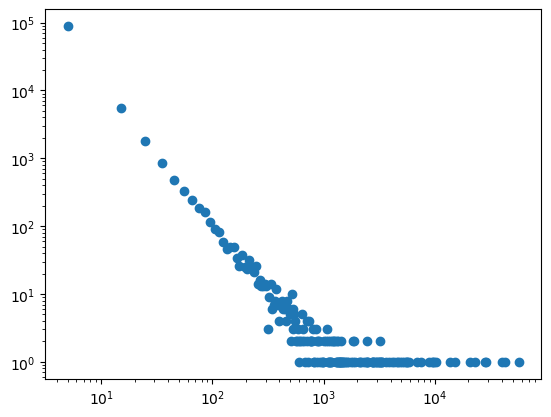

/tmp/ipykernel_573483/2618985646.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


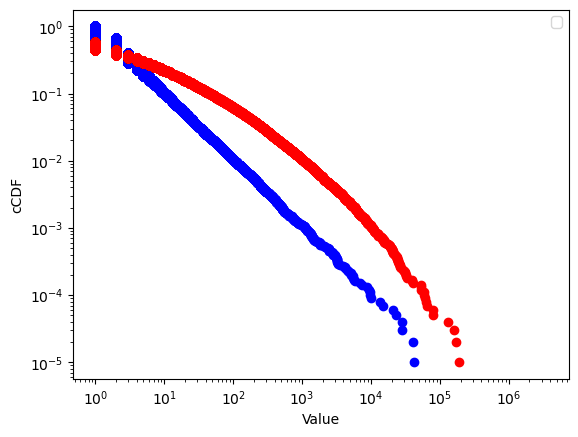

In [11]:

def rndm(xmin, xmax, a, size=1):
    """Power-law gen for pdf(x)~ x^{a-1} for xmin<=x<=xmax"""
    r = np.random.random(size=size)
    xmin_a, xmax_a = xmin**a, xmax**a
    return (xmin_a + (xmax_a - xmin_a)*r)**(1./a)

degreeDistPower = rndm(xmin = 1, xmax = 100000, a=-1, size=100000)
degreeDistLogn = np.random.lognormal(mean = 0, sigma = 3, size=100000)
degreeDistPower = np.round(degreeDistPower)
degreeDistLogn = np.round(degreeDistLogn)

plt.hist(degreeDistCooc, bins = 50)
plt.yscale('log')
plt.show()

binwidth = 10
bin_edges = np.arange(0, np.max(degreeDistPower) + binwidth, binwidth)
empiricalPDF, _ = np.histogram(degreeDistPower, bins=bin_edges)

plt.scatter(x = [edge + binwidth/2 for edge in bin_edges[0:-1]],
            y = empiricalPDF)
plt.xscale('log')
plt.yscale('log')
plt.show()


# Compute CDF
sorted_data_pow = np.sort(degreeDistPower)
cdf = np.arange(1, len(degreeDistPower) + 1) / len(degreeDistPower)
ccdf_pow = 1-cdf

sorted_data_logn = np.sort(degreeDistLogn)
cdf = np.arange(1, len(degreeDistLogn) + 1) / len(degreeDistLogn)
ccdf_logn = 1-cdf

# Plot
plt.scatter(sorted_data_pow, ccdf_pow, c = "blue")
plt.scatter(sorted_data_logn, ccdf_logn, c = "red")
plt.xlabel('Value')
plt.ylabel('cCDF')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

actually fit power law and test against other distribution

In [13]:
degreeDistLogn = np.random.lognormal(mean = 0, sigma = 3, size = 100000)
degreeDistLogn = np.round(degreeDistLogn)

powLaw_power = powerlaw.Fit(degreeDistLogn, discrete = True)
#powLaw_power = powerlaw.Fit(degreeDistLogn, discrete = True)

print(powLaw_power.power_law.alpha)
print(powLaw_power.power_law.xmin)
len([d for d in degreeDistPower if d>powLaw_power.power_law.xmin])
R_exp_power, p_exp_power = powLaw_power.distribution_compare('power_law', 'exponential')
R_logn_power, p_logn_power = powLaw_power.distribution_compare('power_law', 'lognormal')
R_trunc_power, p_trunc_power = powLaw_power.distribution_compare('power_law', 'truncated_power_law')

print(f'For test power law versus exponential: R={R_exp_power} and p={p_exp_power}')
print(f'For test power law versus lognormal: R={R_logn_power} and p={p_logn_power}')
print(f'For test power law versus truncated power law: R={R_trunc_power} and p={p_trunc_power}')

Values less than or equal to 0 in data. Throwing out 0 or negative values
Calculating best minimal value for power law fit


1.9453179533445732
668.0


Assuming nested distributions


For test power law versus exponential: R=1265.8213000038982 and p=0.0021704989331851245
For test power law versus lognormal: R=-8.705130642355977 and p=0.04490760473025295
For test power law versus truncated power law: R=-1.3946444930840034 and p=0.09489632435056894


Using their data from the Clauset et al paper

In [ ]:
#scratch

from os import listdir
files = listdir('.')
if 'blackouts.txt' not in files:
    import urllib
    urllib.urlretrieve('https://raw.github.com/jeffalstott/powerlaw/master/manuscript/blackouts.txt', 'blackouts.txt')



from numpy import genfromtxt
blackouts = genfromtxt('blackouts.txt')/10**3

data = blackouts.astype(float)
####
import powerlaw
fit = powerlaw.Fit(data)
fit.power_law.alpha
fit.power_law.sigma
fit.distribution_compare('power_law', 'exponential')

# print(f"Data range: {data.min()} to {data.max()}")
# print(f"Data size: {len(data)}")
# print(f"Any zeros: {np.any(data == 0)}")
# print(f"Any negatives: {np.any(data < 0)}")
plt.hist(data)